CWD = /home/clara/Research2.0/fyp_fl_smart_home
[OK] Loaded results/casas_fedavg_r50_iid.csv, rounds=50
[OK] Loaded results/casas_fedprox_r50_iid.csv, rounds=50
[OK] Loaded results/casas_scaffold_r50_iid.csv, rounds=50
[OK] Loaded results/casas_feddc_r50_iid.csv, rounds=50


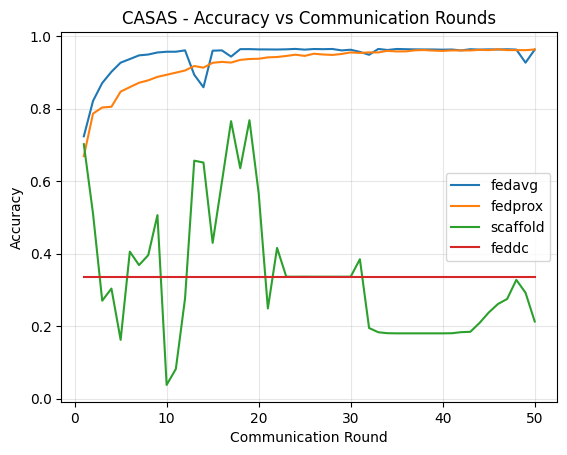

[SAVED] results/plots/casas_compare_accuracy.png


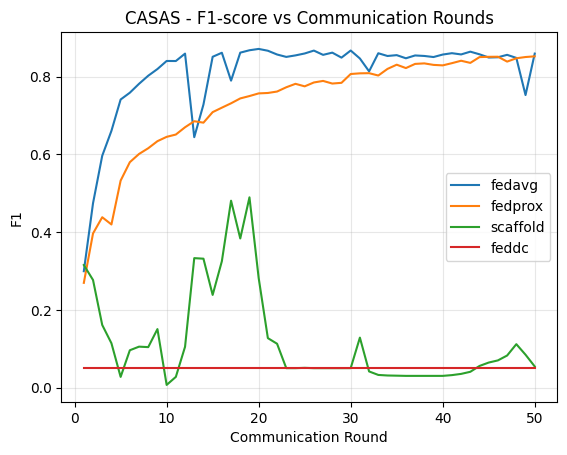

[SAVED] results/plots/casas_compare_f1.png


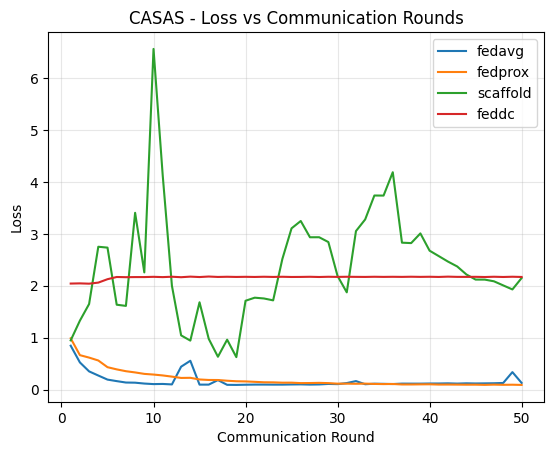

[SAVED] results/plots/casas_compare_loss.png


In [2]:
import os
os.chdir("/home/clara/Research2.0/fyp_fl_smart_home")
print("CWD =", os.getcwd())
import pandas as pd
import matplotlib.pyplot as plt



RESULTS_DIR = "results"
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

ALGOS = ["fedavg", "fedprox", "scaffold", "feddc"]
DATASET = "casas"   #base on algorithm

dfs = {}

for algo in ALGOS:
    csv_path = os.path.join(RESULTS_DIR, f"{DATASET}_{algo}_r50_iid.csv")
    if not os.path.exists(csv_path):
        print(f"[WARN] 找不到 {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    df["round"] = df["round"].astype(int)
    for col in ["loss", "accuracy", "f1"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    dfs[algo] = df
    print(f"[OK] Loaded {csv_path}, rounds={df['round'].max()}")

if len(dfs) < 2:
    raise RuntimeError("至少需要 2 个算法 CSV 才能画对比图")

# -------- 画图函数 --------
def plot_metric(metric: str, title: str, out_name: str):
    plt.figure()
    for algo, df in dfs.items():
        plt.plot(df["round"], df[metric], label=algo)
    plt.xlabel("Communication Round")
    plt.ylabel(metric.capitalize())
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    out_path = os.path.join(PLOTS_DIR, out_name)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {out_path}")

# -------- 三张论文图 --------
plot_metric(
    "accuracy",
    f"{DATASET.upper()} - Accuracy vs Communication Rounds",
    f"{DATASET}_compare_accuracy.png",
)

plot_metric(
    "f1",
    f"{DATASET.upper()} - F1-score vs Communication Rounds",
    f"{DATASET}_compare_f1.png",
)

plot_metric(
    "loss",
    f"{DATASET.upper()} - Loss vs Communication Rounds",
    f"{DATASET}_compare_loss.png",
)


In [4]:
import os
import pandas as pd
# =========================
BASE = "/home/clara/Research2.0/fyp_fl_smart_home"
CSV_MAP = {
    "fedavg":   os.path.join(BASE, "results/casas_fedavg_r50_iid.csv"),
    "fedprox":  os.path.join(BASE, "results/casas_fedprox_r50_iid.csv"),
    "scaffold": os.path.join(BASE, "results/casas_scaffold_r50_iid.csv"),
    "feddc":    os.path.join(BASE, "results/casas_feddc_r50_iid.csv"),
}
# read csv file
def load_csv(fp: str) -> pd.DataFrame:
    if not os.path.exists(fp):
        raise FileNotFoundError(f"❌ CSV not found: {fp}")
    df = pd.read_csv(fp)
    # 标准化列
    df["round"] = df["round"].astype(int)
    for col in ["loss", "accuracy", "f1"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    # sort
    df = (
        df.dropna(subset=["loss", "accuracy", "f1"])
          .sort_values("round")
          .reset_index(drop=True)
    )
    return df


# summary
rows = []

for algo, fp in CSV_MAP.items():
    df = load_csv(fp)

    # 截取最后 10 轮的数据 (如果总共不到10轮，就取全部)
    last_10_df = df.tail(10)
    
    # 计算这 10 轮各项指标的平均值
    avg_accuracy = last_10_df["accuracy"].mean()
    avg_f1 = last_10_df["f1"].mean()
    avg_loss = last_10_df["loss"].mean()

    rows.append({
        "Algorithm": algo.upper(),
        "Metric_Type": "Avg (Last 10 Rounds)", # 标明这是平均值，彰显严谨性
        "Accuracy": round(float(avg_accuracy), 4),
        "F1-score": round(float(avg_f1), 4),
        "Loss": round(float(avg_loss), 4),
        "CSV_file": os.path.basename(fp),
    })

summary_df = (
    pd.DataFrame(rows)
      .sort_values("Algorithm")
      .reset_index(drop=True)
)

# outcome
print("\n=== Federated Learning Final Performance Summary ===\n")
print(summary_df.to_string()) 

# save as csv file
out_path = os.path.join(BASE, "results/summary_casas_iid_fl_algorithms.csv")
summary_df.to_csv(out_path, index=False)
print(f"\n[SAVED] {out_path}")



=== Federated Learning Final Performance Summary ===

  Algorithm           Metric_Type  Accuracy  F1-score    Loss                    CSV_file
0    FEDAVG  Avg (Last 10 Rounds)    0.9595    0.8451  0.1453    casas_fedavg_r50_iid.csv
1     FEDDC  Avg (Last 10 Rounds)    0.3363    0.0503  2.1717     casas_feddc_r50_iid.csv
2   FEDPROX  Avg (Last 10 Rounds)    0.9618    0.8449  0.0969   casas_fedprox_r50_iid.csv
3  SCAFFOLD  Avg (Last 10 Rounds)    0.2362    0.0635  2.2036  casas_scaffold_r50_iid.csv

[SAVED] /home/clara/Research2.0/fyp_fl_smart_home/results/summary_casas_iid_fl_algorithms.csv
